***

## NLP - PRACTICAL 3 - WORD EMBEDDINGS

***

## aim:

To represent words as dense numerical vectors using Word2Vec and GloVe, compare word similarity, solve word analogies, and visualize word embeddings.

## problem statement:

Load pretrained Word2Vec and GloVe embeddings, find semantically similar words, calculate cosine similarity, perform vector-based analogies, visualize embeddings in two dimensions, and train Word2Vec models on a small corpus using CBOW and Skip-gram.

***

## 1. importing libraries

In [1]:
# Gensim provides pretrained and trainable word-embedding models
import numpy as np
import matplotlib.pyplot as plt

from gensim.models import Word2Vec
import gensim.downloader as api

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings("ignore")

## 2. loading pretrained word2vec

In [2]:
# Load a pretrained Word2Vec model
word2vec = api.load("word2vec-google-news-300")

print("Vocabulary size:", len(word2vec))
print("Vector size:", word2vec.vector_size)

Vocabulary size: 3000000
Vector size: 300


## 3. loading pretrained glove

In [3]:
# Load pretrained GloVe vectors
glove = api.load("glove-wiki-gigaword-100")

print("Vocabulary size:", len(glove))
print("Vector size:", glove.vector_size)

[==================================================] 100.0% 128.1/128.1MB downloaded
Vocabulary size: 400000
Vector size: 100


## 4. word similarity

In [4]:
# Find words located close to a given word in vector space
for word in ["king", "computer", "happy"]:
    print(f"\nSimilar words to '{word}':")
    for similar_word, score in word2vec.most_similar(word, topn=5):
        print(similar_word, round(score, 4))


Similar words to 'king':
kings 0.7138
queen 0.6511
monarch 0.6413
crown_prince 0.6204
prince 0.616

Similar words to 'computer':
computers 0.7979
laptop 0.664
laptop_computer 0.6549
Computer 0.6473
com_puter 0.6082

Similar words to 'happy':
glad 0.7409
pleased 0.6632
ecstatic 0.6627
overjoyed 0.6599
thrilled 0.6514


## 5. cosine similarity

In [5]:
# Cosine similarity measures how close two word vectors are
def cosine_similarity(vec_a, vec_b):
    dot = np.dot(vec_a, vec_b)
    norm_a = np.linalg.norm(vec_a)
    norm_b = np.linalg.norm(vec_b)

    return dot / (norm_a * norm_b)

pairs = [
    ("king", "queen"),
    ("king", "man"),
    ("man", "woman"),
    ("paris", "france"),
    ("king", "banana") ]

for w1, w2 in pairs:
    score = cosine_similarity(glove[w1], glove[w2])
    print(w1, w2, round(score, 4))

king queen 0.7508
king man 0.5119
man woman 0.8323
paris france 0.7482
king banana 0.1609


## 6. word2vec vs glove

In [6]:
# Compare similarity scores from two embedding spaces
for w1, w2 in pairs:
    glove_score = glove.similarity(w1, w2)
    w2v_score = word2vec.similarity(w1, w2)

    print(
        f"{w1:10} {w2:10} "
        f"GloVe={glove_score:.4f} "
        f"Word2Vec={w2v_score:.4f}"  )

king       queen      GloVe=0.7508 Word2Vec=0.6511
king       man        GloVe=0.5119 Word2Vec=0.2294
man        woman      GloVe=0.8323 Word2Vec=0.7664
paris      france     GloVe=0.7482 Word2Vec=0.5551
king       banana     GloVe=0.1609 Word2Vec=0.1365


## 7. word analogy

In [7]:
# Vector arithmetic can capture relationships between words
# king - man + woman ≈ queen
results = word2vec.most_similar( positive=["king", "woman"],
                                negative=["man"],
                                topn=5 )

print("king - man + woman = ?")

for word, score in results:
    print(word, round(score, 4))

king - man + woman = ?
queen 0.7118
monarch 0.619
princess 0.5902
crown_prince 0.5499
prince 0.5377


## 8. custom analogy

In [8]:
# The same positive/negative format works for other analogies
positive = ["queen", "man"]
negative = ["woman"]

for word, score in glove.most_similar( positive=positive, negative=negative,topn=5):
    print(word, round(score, 4))
    

king 0.7976
royal 0.6835
prince 0.6819
crown 0.6372
princess 0.6252


## 9. visualize embeddings using pca

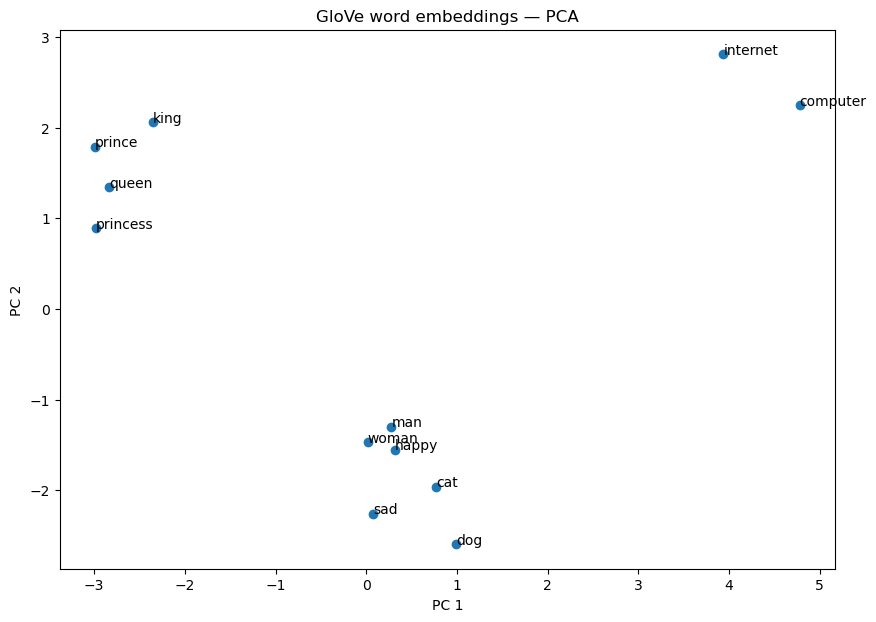

In [9]:
# PCA reduces high-dimensional vectors to two dimensions for visualization
words = [
    "king", "queen", "prince", "princess",
    "man", "woman", "dog", "cat",
    "happy", "sad", "computer", "internet"
]

words = [word for word in words if word in glove]

vectors = np.array([glove[word] for word in words])

pca = PCA(n_components=2, random_state=42)
vectors_2d = pca.fit_transform(vectors)

plt.figure(figsize=(10, 7))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1])

for i, word in enumerate(words):
    plt.annotate(
        word,
        (vectors_2d[i, 0], vectors_2d[i, 1]) )

plt.title("GloVe word embeddings — PCA")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.show()

## 10. training word2vec - cbow and skip-gram

In [10]:
# A small tokenized corpus for demonstrating Word2Vec training
corpus = [
    "I like watching movies".lower().split(),
    "I like watching cricket".lower().split(),
    "I enjoy playing cricket".lower().split(),
    "She enjoys watching movies".lower().split(),
    "Cricket is a popular sport".lower().split()
]

# CBOW predicts the center word from surrounding context
cbow_model = Word2Vec( sentences=corpus,  vector_size=50,  window=3, min_count=1, 
                      sg=0, epochs=100, seed=42)

# Skip-gram predicts surrounding context from the center word
skipgram_model = Word2Vec( sentences=corpus, vector_size=50, window=3,
                          min_count=1, sg=1, epochs=100,seed=42)

print("CBOW vocabulary:", len(cbow_model.wv))
print("Skip-gram vocabulary:", len(skipgram_model.wv))

CBOW vocabulary: 13
Skip-gram vocabulary: 13


## 11. inspect and save the trained model

In [11]:
# Each word now has a dense vector representation
word = "cricket"

print("CBOW vector:", cbow_model.wv[word][:10])
print("Skip-gram vector:", skipgram_model.wv[word][:10])

# Save models for later use
cbow_model.save("cbow_word2vec.model")
skipgram_model.save("skipgram_word2vec.model")

print("Models saved successfully.")

CBOW vector: [-0.01639034  0.01089625  0.00620879 -0.00250451 -0.00259083  0.01436527
 -0.0165851   0.00790386 -0.01198459 -0.01619568]
Skip-gram vector: [-0.01638141  0.01089164  0.00621835 -0.00251092 -0.00258536  0.01438002
 -0.01660173  0.00792786 -0.01199244 -0.01617873]
Models saved successfully.


***

## output:

The program produces:
- vocabulary and vector dimensions
- nearest words for selected words
- cosine similarity values
- analogy results
- a 2D PCA visualization
- CBOW and Skip-gram vocabularies/vectors
- saved Word2Vec model files

***

## result:

Word embeddings were successfully loaded, compared and visualized. Word2Vec models using CBOW and Skip-gram were also trained on a sample corpus and saved for future use.

## observation:

Word embeddings represent words as dense vectors in which semantically or contextually related words tend to be close together. Word2Vec and GloVe can produce different similarity values because they use different training approaches and corpora. PCA provides a two-dimensional view of the high-dimensional embedding space. CBOW predicts a target word from its context, while Skip-gram predicts context words from a target word.

***

## viva questions:

1. **What is a word embedding?**  
   A dense numerical vector representation of a word that captures relationships learned from text.

2. **Why are embeddings better than simple one-hot vectors?**  
   They are dense and can capture similarity/relationships between words.

3. **What is Word2Vec?**  
   A neural word-embedding method that learns word vectors from surrounding context.

4. **What are CBOW and Skip-gram?**  
   CBOW predicts a target word from surrounding context; Skip-gram predicts surrounding words from a target word.

5. **What does `sg=0` mean?**  
   CBOW.

6. **What does `sg=1` mean?**  
   Skip-gram.

7. **What is `vector_size`?**  
   The number of dimensions in each word vector.

8. **What is `window`?**  
   The size of the surrounding context considered during training.

9. **What is `min_count`?**  
   The minimum frequency required for a word to be included in training.

10. **What is GloVe?**  
    A word-embedding method based on global word co-occurrence statistics.

11. **Word2Vec vs GloVe?**  
    Word2Vec learns from local context prediction, while GloVe uses global co-occurrence information.

12. **What is cosine similarity?**  
    A measure of similarity between vectors based on their angle.

13. **What is a word analogy?**  
    A relationship represented through vector arithmetic, such as `king - man + woman ≈ queen`.

14. **Why use PCA?**  
    To reduce high-dimensional vectors to fewer dimensions for visualization.

15. **Why use t-SNE?**  
    To visualize high-dimensional data while preserving local neighbourhood structure.

16. **Why can a word be missing from a pretrained model?**  
    It may not exist in that model's vocabulary.

17. **Why is a large corpus needed for good embeddings?**  
    More contextual examples allow the model to learn richer semantic relationships.

***